# Concurrent NN Compression for Spatio-Temporal Data — Online Training & Evaluation
Streaming in-situ training with temporal windows.
- **Base Model**: 4 → 64 → 64 → 32 → 4 (6,692 parameters)
- **Medium Model**: 4 → 96 → 96 → 48 → 4 (14,644 parameters)
- **Large Model**: 4 → 128 → 128 → 64 → 4 (25,668 parameters)

In [1]:
"""Unified Training Utilities for Concurrent NN Compression for Spatio-Temporal Data"""

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
import pyarrow.csv as pv
from torcheval.metrics import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure
import matplotlib.pyplot as plt
import time
import os
import json


class SpatioTemporalDataset(Dataset):
    """Spatio-temporal spatio-temporal dataset with min-max normalization to [0, 1]."""

    def __init__(self, filepath):
        print(f"[Data] Loading dataset from {filepath}")
        read_options = pv.ReadOptions(
            column_names=['x', 'y', 'z', 't', 'Vx', 'Vy', 'Pressure', 'TKE']
        )
        table = pv.read_csv(filepath, read_options=read_options)
        data = table.to_pandas().values
        self.inputs = data[:, :4].astype(np.float32)
        self.targets = data[:, 4:].astype(np.float32)
        print("[Data] Applying min-max normalization to [0, 1] range")
        self.input_min = self.inputs.min(axis=0)
        self.input_max = self.inputs.max(axis=0)
        self.input_range = self.input_max - self.input_min
        self.input_range[self.input_range == 0] = 1.0
        self.inputs = (self.inputs - self.input_min) / self.input_range
        self.target_min = self.targets.min(axis=0)
        self.target_max = self.targets.max(axis=0)
        self.target_range = self.target_max - self.target_min
        self.target_range[self.target_range == 0] = 1.0
        self.targets = (self.targets - self.target_min) / self.target_range
        print(f"[Data] Loaded {len(self):,} samples | Input: {self.inputs.shape} | Target: {self.targets.shape}")

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return torch.from_numpy(self.inputs[idx]), torch.from_numpy(self.targets[idx])

    def denormalize_inputs(self, normalized):
        if isinstance(normalized, torch.Tensor):
            normalized = normalized.cpu().numpy()
        return normalized * self.input_range + self.input_min

    def denormalize_targets(self, normalized):
        if isinstance(normalized, torch.Tensor):
            normalized = normalized.cpu().numpy()
        return normalized * self.target_range + self.target_min


class BaseCompressor(nn.Module):
    """Base compression network: 4 -> 64 -> 64 -> 32 -> 4"""

    def __init__(self):
        super(BaseCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        return self.network(x)


class MediumCompressor(nn.Module):
    """Medium compression network: 4 -> 96 -> 96 -> 48 -> 4"""

    def __init__(self):
        super(MediumCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 96),
            nn.ReLU(),
            nn.Linear(96, 96),
            nn.ReLU(),
            nn.Linear(96, 48),
            nn.ReLU(),
            nn.Linear(48, 4)
        )

    def forward(self, x):
        return self.network(x)


class LargeCompressor(nn.Module):
    """Large compression network: 4 -> 128 -> 128 -> 64 -> 4"""

    def __init__(self):
        super(LargeCompressor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.network(x)


def compute_psnr_ssim(predictions, targets, device):
    """Compute PSNR and SSIM for regression data using per-point comparison (kernel_size=1)."""
    predictions = predictions.to(device)
    targets = targets.to(device)

    psnr_metric = PeakSignalNoiseRatio().to(device)
    psnr_metric.update(predictions, targets)
    psnr = psnr_metric.compute().item()

    pred_ssim = predictions.view(-1, 1, 1, predictions.shape[1])
    target_ssim = targets.view(-1, 1, 1, targets.shape[1])
    pred_ssim = pred_ssim.permute(1, 2, 0, 3)
    target_ssim = target_ssim.permute(1, 2, 0, 3)

    ssim_metric = StructuralSimilarityIndexMeasure(
        gaussian_kernel=False, kernel_size=1
    ).to(device)
    ssim_metric.update(pred_ssim, target_ssim)
    ssim = ssim_metric.compute().item()

    return psnr, ssim


def compute_relative_error(predictions, targets):
    """Compute relative L2 norm error as a percentage."""
    target_norm = torch.norm(targets)
    error = torch.norm(predictions - targets)
    return (error / target_norm * 100).item()


def train_online(model, dataset, device, epochs_per_window, model_name, output_dir, num_windows=20):
    """Train a compression model using online streaming with temporal windows."""
    os.makedirs(output_dir, exist_ok=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    all_metrics = {
        'window': [],
        'loss': [],
        'psnr': [],
        'ssim': [],
        'relative_error': [],
        'time_per_window': []
    }

    total_params = sum(p.numel() for p in model.parameters())
    print(f"\n[Train] Model: {model_name}")
    print(f"[Train] Samples: {len(dataset):,} | Windows: {num_windows} | Epochs/Window: {epochs_per_window}")
    print(f"[Train] Device: {device} | Parameters: {total_params:,} | Size: {total_params * 4 / 1024:.2f} KB")

    coords_denorm = dataset.denormalize_inputs(dataset.inputs)
    unique_times = np.unique(coords_denorm[:, 3])
    times_per_window = len(unique_times) // num_windows
    print(f"[Train] Unique timesteps: {len(unique_times)} | Timesteps/Window: {times_per_window}\n")

    for window_idx in range(num_windows):
        window_start_time = time.time()

        start_idx = window_idx * times_per_window
        end_idx = start_idx + times_per_window if window_idx < num_windows - 1 else len(unique_times)
        window_times = unique_times[start_idx:end_idx]

        time_mask = np.isin(coords_denorm[:, 3], window_times)
        window_inputs = torch.from_numpy(dataset.inputs[time_mask]).to(device)
        window_targets = torch.from_numpy(dataset.targets[time_mask]).to(device)

        print(f"  Window {window_idx+1:>2}/{num_windows}: {len(window_inputs):,} samples, "
              f"t=[{window_times[0]:.4f}, {window_times[-1]:.4f}]")

        for epoch in range(epochs_per_window):
            model.train()
            optimizer.zero_grad()
            outputs = model(window_inputs)
            loss = criterion(outputs, window_targets)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            predictions = model(window_inputs)

        loss_val = criterion(predictions, window_targets).item()
        psnr, ssim = compute_psnr_ssim(predictions, window_targets, device)
        rel_error = compute_relative_error(predictions, window_targets)

        window_time = time.time() - window_start_time

        all_metrics['window'].append(window_idx + 1)
        all_metrics['loss'].append(loss_val)
        all_metrics['psnr'].append(psnr)
        all_metrics['ssim'].append(ssim)
        all_metrics['relative_error'].append(rel_error)
        all_metrics['time_per_window'].append(window_time)

        print(f"           Loss={loss_val:.6f}, PSNR={psnr:.2f} dB, SSIM={ssim:.4f}, "
              f"Rel. Error={rel_error:.2f}%, Time={window_time:.2f}s")

        window_dir = os.path.join(output_dir, f'window_{window_idx+1:02d}')
        os.makedirs(window_dir, exist_ok=True)
        torch.save(model.state_dict(),
                   os.path.join(window_dir, f'{model_name}_window_{window_idx+1:02d}.pth'))

    final_model_path = os.path.join(output_dir, f'{model_name}_online_final.pth')
    torch.save(model.state_dict(), final_model_path)
    print(f"\n[Train] Final model saved: {final_model_path}")

    norm_params = {
        'input_min': dataset.input_min.tolist(),
        'input_max': dataset.input_max.tolist(),
        'input_range': dataset.input_range.tolist(),
        'target_min': dataset.target_min.tolist(),
        'target_max': dataset.target_max.tolist(),
        'target_range': dataset.target_range.tolist()
    }
    norm_path = os.path.join(output_dir, f'{model_name}_normalization.json')
    with open(norm_path, 'w') as f:
        json.dump(norm_params, f, indent=2)
    print(f"[Train] Normalization parameters saved: {norm_path}")

    summary = {
        'model_name': model_name,
        'total_windows': num_windows,
        'epochs_per_window': epochs_per_window,
        'total_epochs': num_windows * epochs_per_window,
        'final_loss': all_metrics['loss'][-1],
        'final_psnr': all_metrics['psnr'][-1],
        'final_ssim': all_metrics['ssim'][-1],
        'final_relative_error': all_metrics['relative_error'][-1],
        'total_training_time': sum(all_metrics['time_per_window']),
        'avg_time_per_window': np.mean(all_metrics['time_per_window'])
    }
    summary_path = os.path.join(output_dir, 'online_training_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)

    print(f"\n[Train] Online training completed for {model_name}")
    print(f"  Total Windows:        {num_windows}")
    print(f"  Total Epochs:         {num_windows * epochs_per_window}")
    print(f"  Final Loss:           {all_metrics['loss'][-1]:.6f}")
    print(f"  Final PSNR:           {all_metrics['psnr'][-1]:.2f} dB")
    print(f"  Final SSIM:           {all_metrics['ssim'][-1]:.4f}")
    print(f"  Final Relative Error: {all_metrics['relative_error'][-1]:.2f}%")
    print(f"  Total Time:           {sum(all_metrics['time_per_window']):.2f}s\n")

    return all_metrics


def export_metrics_csv(metrics, output_path):
    """Export training metrics history to CSV."""
    df = pd.DataFrame(metrics)
    df.to_csv(output_path, index=False)
    print(f"[Export] Metrics saved: {output_path}")

In [2]:
DATA_FILE = "/kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv"
EPOCHS_PER_WINDOW = 100
NUM_WINDOWS = 20
TIMESTEP = 0.0396

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[Config] Device: {device}")
print(f"[Config] Epochs/Window: {EPOCHS_PER_WINDOW} | Windows: {NUM_WINDOWS} | Total Epochs: {EPOCHS_PER_WINDOW * NUM_WINDOWS}")

dataset = SpatioTemporalDataset(DATA_FILE)

[Config] Device: cuda
[Config] Epochs/Window: 100 | Windows: 20 | Total Epochs: 2000
[Data] Loading dataset from /kaggle/input/datasets/maheshsadupalli/ml-test-loader-original-data-csv/ML_test_loader_original_data.csv
[Data] Applying min-max normalization to [0, 1] range
[Data] Loaded 7,919,100 samples | Input: (7919100, 4) | Target: (7919100, 4)


---
## 1. Base Model (64-64-32) — Online Training

In [3]:
BASE_OUTPUT_DIR = "/kaggle/working/results/base_model_online"

base_model = BaseCompressor().to(device)

base_metrics = train_online(
    model=base_model,
    dataset=dataset,
    device=device,
    epochs_per_window=EPOCHS_PER_WINDOW,
    model_name='base_model',
    output_dir=BASE_OUTPUT_DIR,
    num_windows=NUM_WINDOWS
)

export_metrics_csv(base_metrics, f"{BASE_OUTPUT_DIR}/base_model_online_metrics.csv")


[Train] Model: base_model
[Train] Samples: 7,919,100 | Windows: 20 | Epochs/Window: 100
[Train] Device: cuda | Parameters: 6,692 | Size: 26.14 KB
[Train] Unique timesteps: 300 | Timesteps/Window: 15

  Window  1/20: 395,955 samples, t=[0.0000, 0.0114]
           Loss=0.008838, PSNR=20.54 dB, SSIM=0.8814, Rel. Error=15.82%, Time=4.03s
  Window  2/20: 395,955 samples, t=[0.0115, 0.0129]
           Loss=0.009330, PSNR=20.30 dB, SSIM=0.8619, Rel. Error=16.39%, Time=1.92s
  Window  3/20: 395,955 samples, t=[0.0130, 0.0144]
           Loss=0.009950, PSNR=20.02 dB, SSIM=0.8538, Rel. Error=17.03%, Time=1.85s
  Window  4/20: 395,955 samples, t=[0.0145, 0.0159]
           Loss=0.010628, PSNR=19.74 dB, SSIM=0.8465, Rel. Error=17.72%, Time=1.86s
  Window  5/20: 395,955 samples, t=[0.0160, 0.0174]
           Loss=0.011206, PSNR=19.51 dB, SSIM=0.8374, Rel. Error=18.36%, Time=1.86s
  Window  6/20: 395,955 samples, t=[0.0175, 0.0189]
           Loss=0.011769, PSNR=19.29 dB, SSIM=0.8234, Rel. Error=19

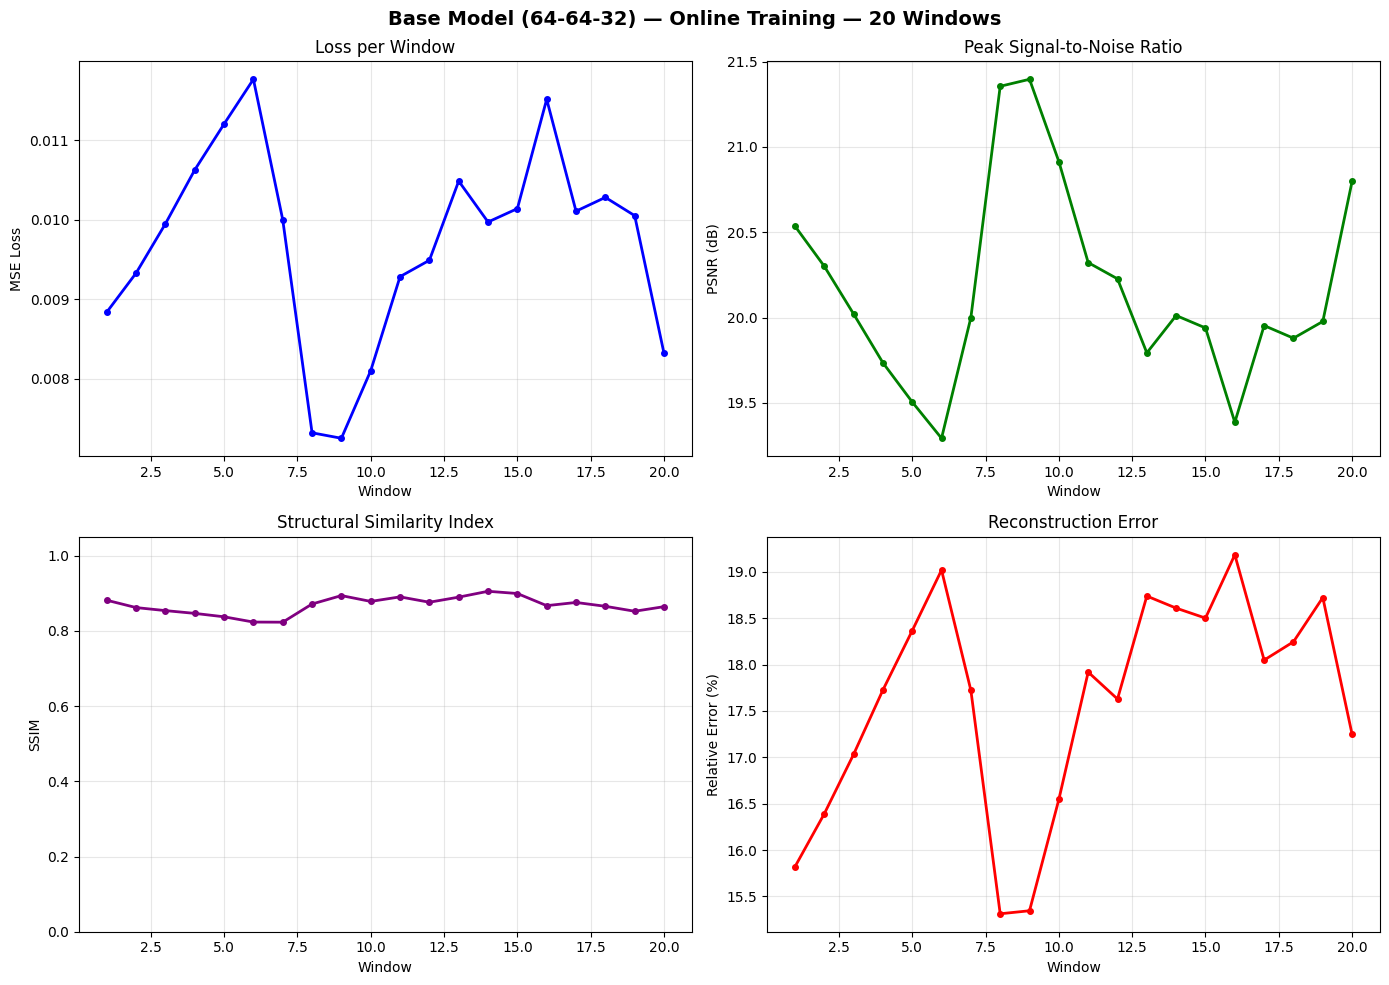

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(base_metrics['window'], base_metrics['loss'], 'b-o', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Window')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Loss per Window')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(base_metrics['window'], base_metrics['psnr'], 'g-o', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Window')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(base_metrics['window'], base_metrics['ssim'], 'purple', linewidth=2, marker='o', markersize=4)
axes[1, 0].set_xlabel('Window')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

axes[1, 1].plot(base_metrics['window'], base_metrics['relative_error'], 'r-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Window')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Base Model (64-64-32) \u2014 Online Training \u2014 {NUM_WINDOWS} Windows',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{BASE_OUTPUT_DIR}/base_model_online_progress.png", dpi=300, bbox_inches='tight')
plt.show()

### 1.1 Base Model — Evaluation & Visualization

In [5]:
base_model.eval()
print(f"[Eval] Base model: {sum(p.numel() for p in base_model.parameters()):,} parameters")

all_inputs = torch.from_numpy(dataset.inputs).to(device)
with torch.no_grad():
    base_predictions = base_model(all_inputs).cpu()

all_targets = torch.from_numpy(dataset.targets)

base_psnr, base_ssim = compute_psnr_ssim(base_predictions, all_targets, device)
base_rel_error = compute_relative_error(base_predictions, all_targets)
print(f"[Eval] PSNR: {base_psnr:.2f} dB | SSIM: {base_ssim:.4f} | Rel. Error: {base_rel_error:.2f}%")

# Use normalized data [0, 1] for visualization
base_pred_norm = base_predictions.numpy()
targets_norm = all_targets.numpy()
coords_denorm = dataset.denormalize_inputs(dataset.inputs)

timestep_mask = np.abs(coords_denorm[:, 3] - TIMESTEP) < 1e-6
x = coords_denorm[timestep_mask, 0]
y = coords_denorm[timestep_mask, 1]
base_pred_t = base_pred_norm[timestep_mask]
target_t = targets_norm[timestep_mask]
base_errors_t = np.abs(target_t - base_pred_t)

print(f"[Eval] Visualizing {len(x):,} points at timestep {TIMESTEP}")

[Eval] Base model: 6,692 parameters
[Eval] PSNR: 17.32 dB | SSIM: 0.8470 | Rel. Error: 24.28%
[Eval] Visualizing 26,397 points at timestep 0.0396


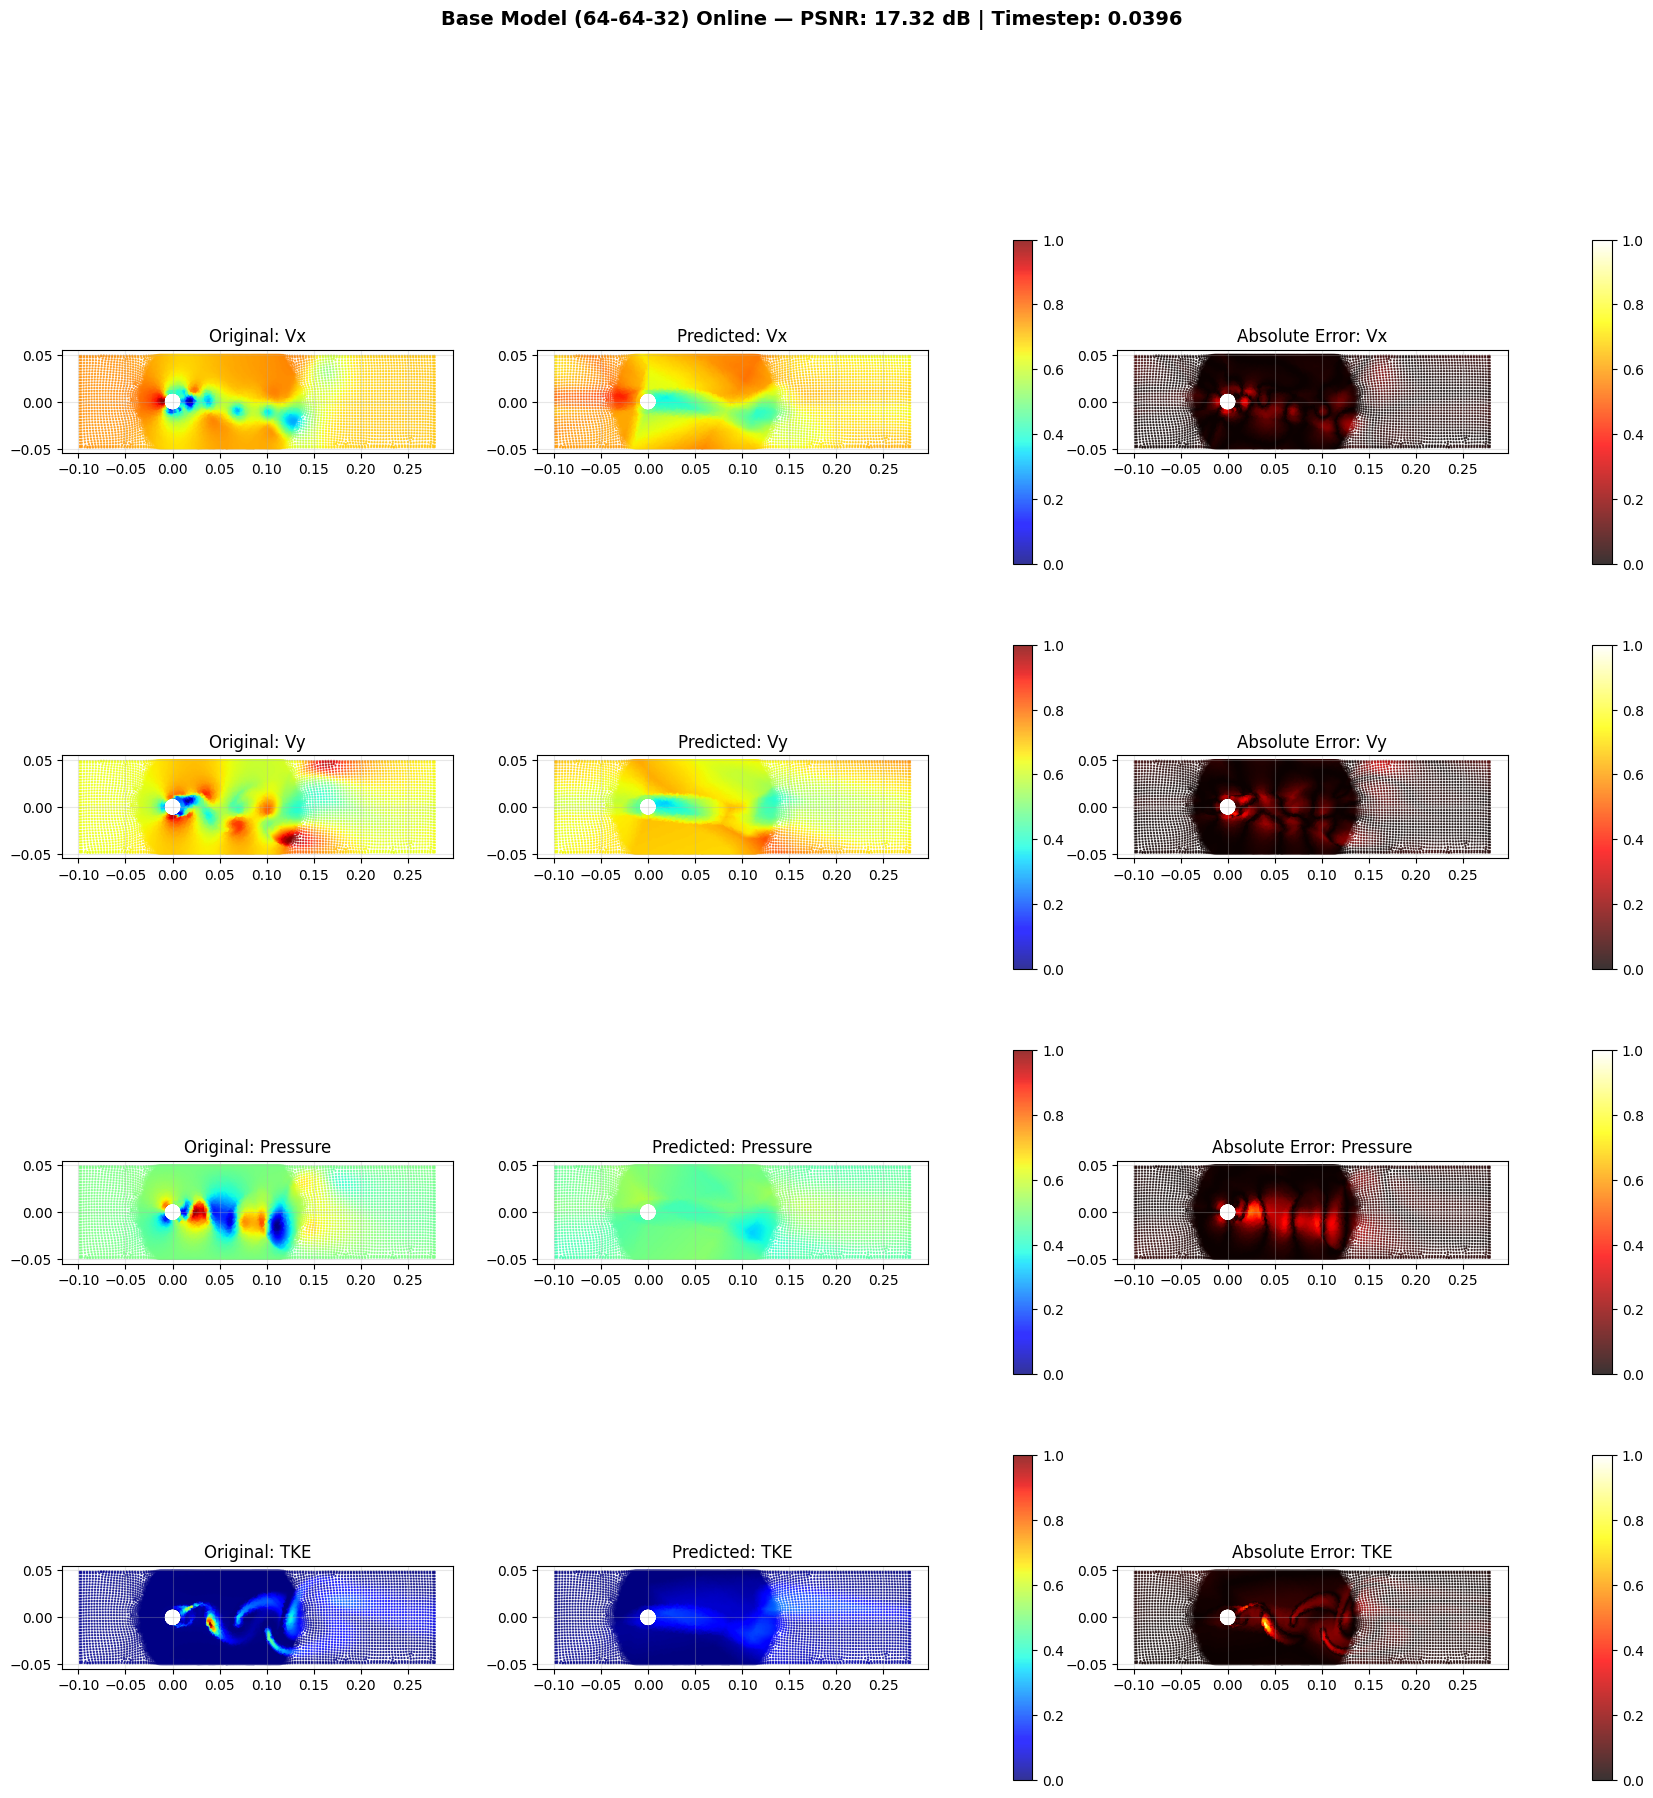

[Eval] Base model evaluation completed


In [6]:
from matplotlib.gridspec import GridSpec

feature_names = ['Vx', 'Vy', 'Pressure', 'TKE']

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(4, 5, figure=fig,
              width_ratios=[1, 1, 0.05, 1, 0.05],
              wspace=0.35, hspace=0.25)

for row, (idx, name) in enumerate(zip(range(4), feature_names)):
    original = target_t[:, idx]
    predicted = base_pred_t[:, idx]
    error = base_errors_t[:, idx]

    ax0 = fig.add_subplot(gs[row, 0])
    ax0.scatter(x, y, c=original, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax0.set_title(f'Original: {name}')
    ax0.set_aspect('equal')
    ax0.grid(True, alpha=0.3)

    ax1 = fig.add_subplot(gs[row, 1])
    sc2 = ax1.scatter(x, y, c=predicted, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax1.set_title(f'Predicted: {name}')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    cax1 = fig.add_subplot(gs[row, 2])
    fig.colorbar(sc2, cax=cax1)

    ax2 = fig.add_subplot(gs[row, 3])
    sc3 = ax2.scatter(x, y, c=error, cmap='hot', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax2.set_title(f'Absolute Error: {name}')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    cax2 = fig.add_subplot(gs[row, 4])
    fig.colorbar(sc3, cax=cax2)

fig.suptitle(f'Base Model (64-64-32) Online — PSNR: {base_psnr:.2f} dB | Timestep: {TIMESTEP}',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(f"{BASE_OUTPUT_DIR}/base_online_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

base_eval = {
    'model': 'base_model_online_final.pth',
    'architecture': '4-64-64-32-4',
    'training_mode': 'online_streaming',
    'parameters': sum(p.numel() for p in base_model.parameters()),
    'psnr_db': float(base_psnr),
    'ssim': float(base_ssim),
    'relative_error_pct': float(base_rel_error)
}
with open(f"{BASE_OUTPUT_DIR}/evaluation_metrics.json", 'w') as f:
    json.dump(base_eval, f, indent=2)
print("[Eval] Base model evaluation completed")

---
## 2. Medium Model (96-96-48) — Online Training

In [7]:
MEDIUM_OUTPUT_DIR = "/kaggle/working/results/medium_model_online"

medium_model = MediumCompressor().to(device)

medium_metrics = train_online(
    model=medium_model,
    dataset=dataset,
    device=device,
    epochs_per_window=EPOCHS_PER_WINDOW,
    model_name='medium_model',
    output_dir=MEDIUM_OUTPUT_DIR,
    num_windows=NUM_WINDOWS
)

export_metrics_csv(medium_metrics, f"{MEDIUM_OUTPUT_DIR}/medium_model_online_metrics.csv")


[Train] Model: medium_model
[Train] Samples: 7,919,100 | Windows: 20 | Epochs/Window: 100
[Train] Device: cuda | Parameters: 14,644 | Size: 57.20 KB
[Train] Unique timesteps: 300 | Timesteps/Window: 15

  Window  1/20: 395,955 samples, t=[0.0000, 0.0114]
           Loss=0.008834, PSNR=20.54 dB, SSIM=0.8776, Rel. Error=15.81%, Time=2.94s
  Window  2/20: 395,955 samples, t=[0.0115, 0.0129]
           Loss=0.009040, PSNR=20.44 dB, SSIM=0.8715, Rel. Error=16.13%, Time=2.88s
  Window  3/20: 395,955 samples, t=[0.0130, 0.0144]
           Loss=0.009250, PSNR=20.34 dB, SSIM=0.8658, Rel. Error=16.42%, Time=2.91s
  Window  4/20: 395,955 samples, t=[0.0145, 0.0159]
           Loss=0.009180, PSNR=20.37 dB, SSIM=0.8382, Rel. Error=16.47%, Time=2.91s
  Window  5/20: 395,955 samples, t=[0.0160, 0.0174]
           Loss=0.008514, PSNR=20.70 dB, SSIM=0.8588, Rel. Error=16.01%, Time=2.93s
  Window  6/20: 395,955 samples, t=[0.0175, 0.0189]
           Loss=0.007735, PSNR=21.12 dB, SSIM=0.8791, Rel. Error

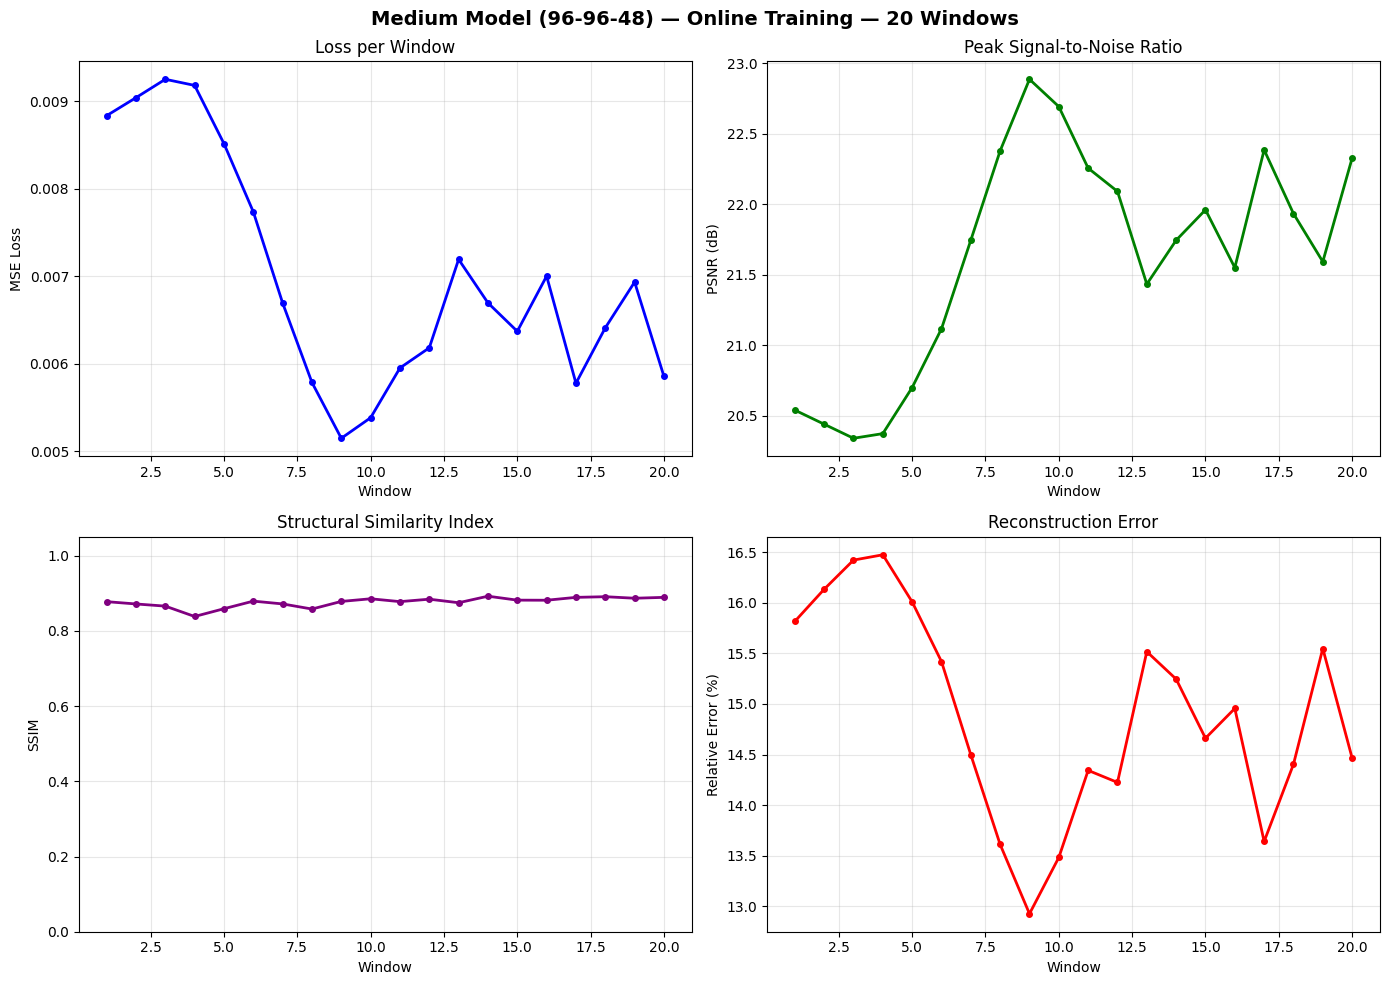

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(medium_metrics['window'], medium_metrics['loss'], 'b-o', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Window')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Loss per Window')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(medium_metrics['window'], medium_metrics['psnr'], 'g-o', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Window')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(medium_metrics['window'], medium_metrics['ssim'], 'purple', linewidth=2, marker='o', markersize=4)
axes[1, 0].set_xlabel('Window')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

axes[1, 1].plot(medium_metrics['window'], medium_metrics['relative_error'], 'r-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Window')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Medium Model (96-96-48) \u2014 Online Training \u2014 {NUM_WINDOWS} Windows',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MEDIUM_OUTPUT_DIR}/medium_model_online_progress.png", dpi=300, bbox_inches='tight')
plt.show()

### 2.1 Medium Model — Evaluation & Visualization

In [9]:
medium_model.eval()
print(f"[Eval] Medium model: {sum(p.numel() for p in medium_model.parameters()):,} parameters")

with torch.no_grad():
    medium_predictions = medium_model(all_inputs).cpu()

medium_psnr, medium_ssim = compute_psnr_ssim(medium_predictions, all_targets, device)
medium_rel_error = compute_relative_error(medium_predictions, all_targets)
print(f"[Eval] PSNR: {medium_psnr:.2f} dB | SSIM: {medium_ssim:.4f} | Rel. Error: {medium_rel_error:.2f}%")

medium_pred_norm = medium_predictions.numpy()
medium_pred_t = medium_pred_norm[timestep_mask]
medium_errors_t = np.abs(target_t - medium_pred_t)

print(f"[Eval] Visualizing {len(x):,} points at timestep {TIMESTEP}")

[Eval] Medium model: 14,644 parameters
[Eval] PSNR: 15.21 dB | SSIM: 0.8083 | Rel. Error: 30.96%
[Eval] Visualizing 26,397 points at timestep 0.0396


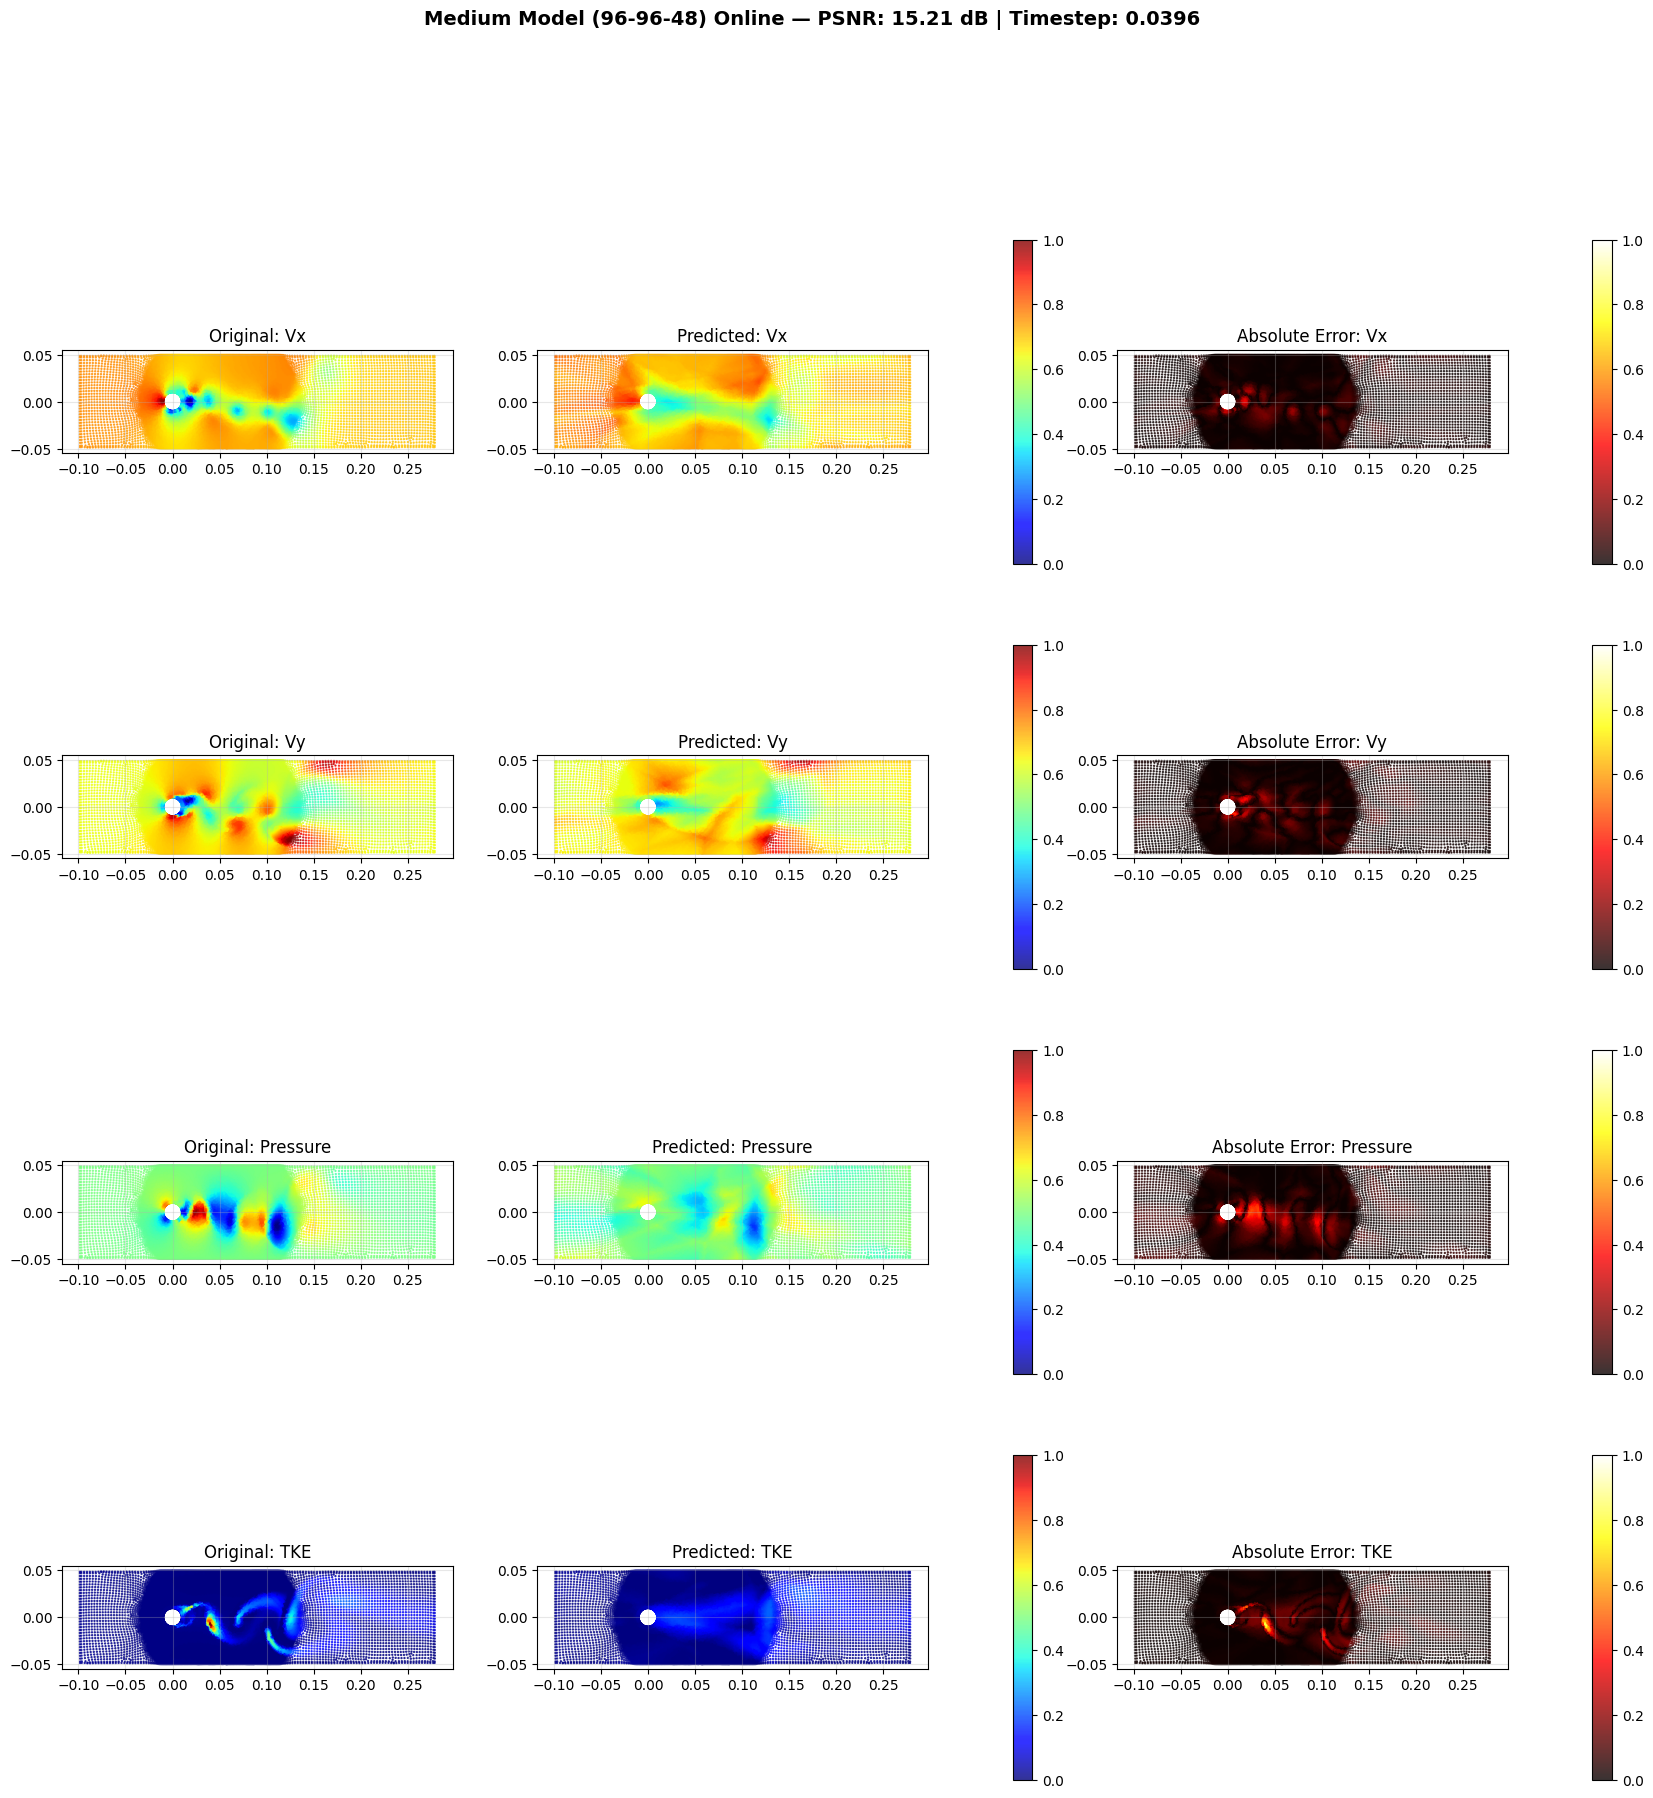

[Eval] Medium model evaluation completed


In [10]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(4, 5, figure=fig,
              width_ratios=[1, 1, 0.05, 1, 0.05],
              wspace=0.35, hspace=0.25)

for row, (idx, name) in enumerate(zip(range(4), feature_names)):
    original = target_t[:, idx]
    predicted = medium_pred_t[:, idx]
    error = medium_errors_t[:, idx]

    ax0 = fig.add_subplot(gs[row, 0])
    ax0.scatter(x, y, c=original, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax0.set_title(f'Original: {name}')
    ax0.set_aspect('equal')
    ax0.grid(True, alpha=0.3)

    ax1 = fig.add_subplot(gs[row, 1])
    sc2 = ax1.scatter(x, y, c=predicted, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax1.set_title(f'Predicted: {name}')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    cax1 = fig.add_subplot(gs[row, 2])
    fig.colorbar(sc2, cax=cax1)

    ax2 = fig.add_subplot(gs[row, 3])
    sc3 = ax2.scatter(x, y, c=error, cmap='hot', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax2.set_title(f'Absolute Error: {name}')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    cax2 = fig.add_subplot(gs[row, 4])
    fig.colorbar(sc3, cax=cax2)

fig.suptitle(f'Medium Model (96-96-48) Online — PSNR: {medium_psnr:.2f} dB | Timestep: {TIMESTEP}',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(f"{MEDIUM_OUTPUT_DIR}/medium_online_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

medium_eval = {
    'model': 'medium_model_online_final.pth',
    'architecture': '4-96-96-48-4',
    'training_mode': 'online_streaming',
    'parameters': sum(p.numel() for p in medium_model.parameters()),
    'psnr_db': float(medium_psnr),
    'ssim': float(medium_ssim),
    'relative_error_pct': float(medium_rel_error)
}
with open(f"{MEDIUM_OUTPUT_DIR}/evaluation_metrics.json", 'w') as f:
    json.dump(medium_eval, f, indent=2)
print("[Eval] Medium model evaluation completed")

---
## 3. Large Model (128-128-64) — Online Training

In [11]:
LARGE_OUTPUT_DIR = "/kaggle/working/results/large_model_online"

large_model = LargeCompressor().to(device)

large_metrics = train_online(
    model=large_model,
    dataset=dataset,
    device=device,
    epochs_per_window=EPOCHS_PER_WINDOW,
    model_name='large_model',
    output_dir=LARGE_OUTPUT_DIR,
    num_windows=NUM_WINDOWS
)

export_metrics_csv(large_metrics, f"{LARGE_OUTPUT_DIR}/large_model_online_metrics.csv")


[Train] Model: large_model
[Train] Samples: 7,919,100 | Windows: 20 | Epochs/Window: 100
[Train] Device: cuda | Parameters: 25,668 | Size: 100.27 KB
[Train] Unique timesteps: 300 | Timesteps/Window: 15

  Window  1/20: 395,955 samples, t=[0.0000, 0.0114]
           Loss=0.008616, PSNR=20.65 dB, SSIM=0.8750, Rel. Error=15.62%, Time=4.00s
  Window  2/20: 395,955 samples, t=[0.0115, 0.0129]
           Loss=0.008899, PSNR=20.51 dB, SSIM=0.8768, Rel. Error=16.01%, Time=4.11s
  Window  3/20: 395,955 samples, t=[0.0130, 0.0144]
           Loss=0.009102, PSNR=20.41 dB, SSIM=0.8645, Rel. Error=16.29%, Time=4.16s
  Window  4/20: 395,955 samples, t=[0.0145, 0.0159]
           Loss=0.009121, PSNR=20.40 dB, SSIM=0.8371, Rel. Error=16.42%, Time=4.16s
  Window  5/20: 395,955 samples, t=[0.0160, 0.0174]
           Loss=0.008582, PSNR=20.66 dB, SSIM=0.8481, Rel. Error=16.07%, Time=4.16s
  Window  6/20: 395,955 samples, t=[0.0175, 0.0189]
           Loss=0.005571, PSNR=22.54 dB, SSIM=0.8506, Rel. Error

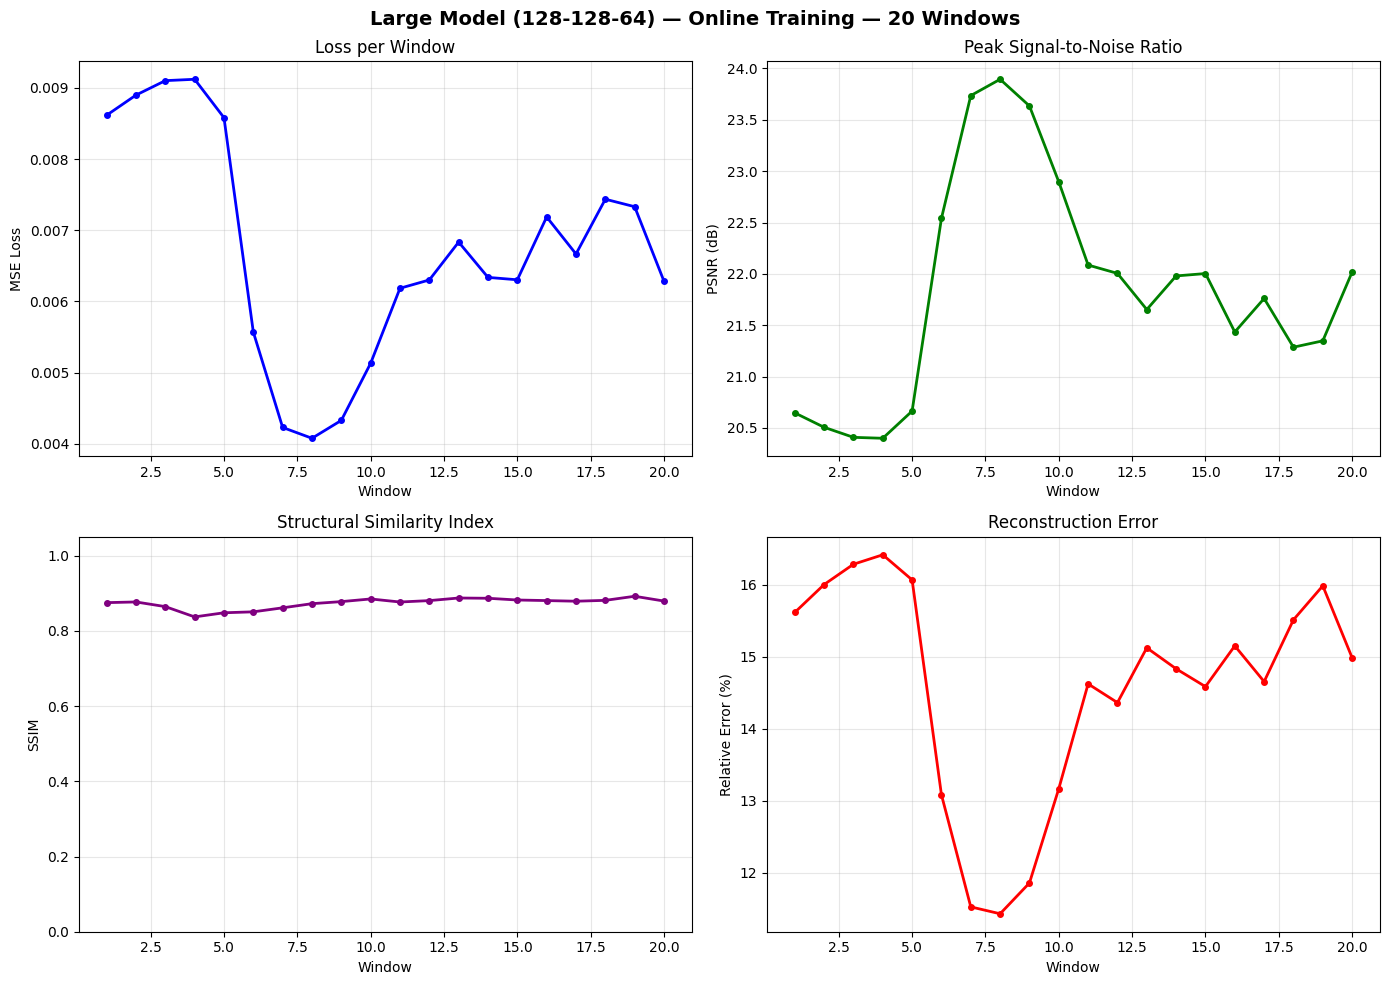

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(large_metrics['window'], large_metrics['loss'], 'b-o', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Window')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Loss per Window')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(large_metrics['window'], large_metrics['psnr'], 'g-o', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Window')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(large_metrics['window'], large_metrics['ssim'], 'purple', linewidth=2, marker='o', markersize=4)
axes[1, 0].set_xlabel('Window')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

axes[1, 1].plot(large_metrics['window'], large_metrics['relative_error'], 'r-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Window')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Large Model (128-128-64) \u2014 Online Training \u2014 {NUM_WINDOWS} Windows',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LARGE_OUTPUT_DIR}/large_model_online_progress.png", dpi=300, bbox_inches='tight')
plt.show()

### 3.1 Large Model — Evaluation & Visualization

In [13]:
large_model.eval()
print(f"[Eval] Large model: {sum(p.numel() for p in large_model.parameters()):,} parameters")

with torch.no_grad():
    large_predictions = large_model(all_inputs).cpu()

large_psnr, large_ssim = compute_psnr_ssim(large_predictions, all_targets, device)
large_rel_error = compute_relative_error(large_predictions, all_targets)
print(f"[Eval] PSNR: {large_psnr:.2f} dB | SSIM: {large_ssim:.4f} | Rel. Error: {large_rel_error:.2f}%")

large_pred_norm = large_predictions.numpy()
large_pred_t = large_pred_norm[timestep_mask]
large_errors_t = np.abs(target_t - large_pred_t)

print(f"[Eval] Visualizing {len(x):,} points at timestep {TIMESTEP}")

[Eval] Large model: 25,668 parameters
[Eval] PSNR: 14.45 dB | SSIM: 0.7926 | Rel. Error: 33.75%
[Eval] Visualizing 26,397 points at timestep 0.0396


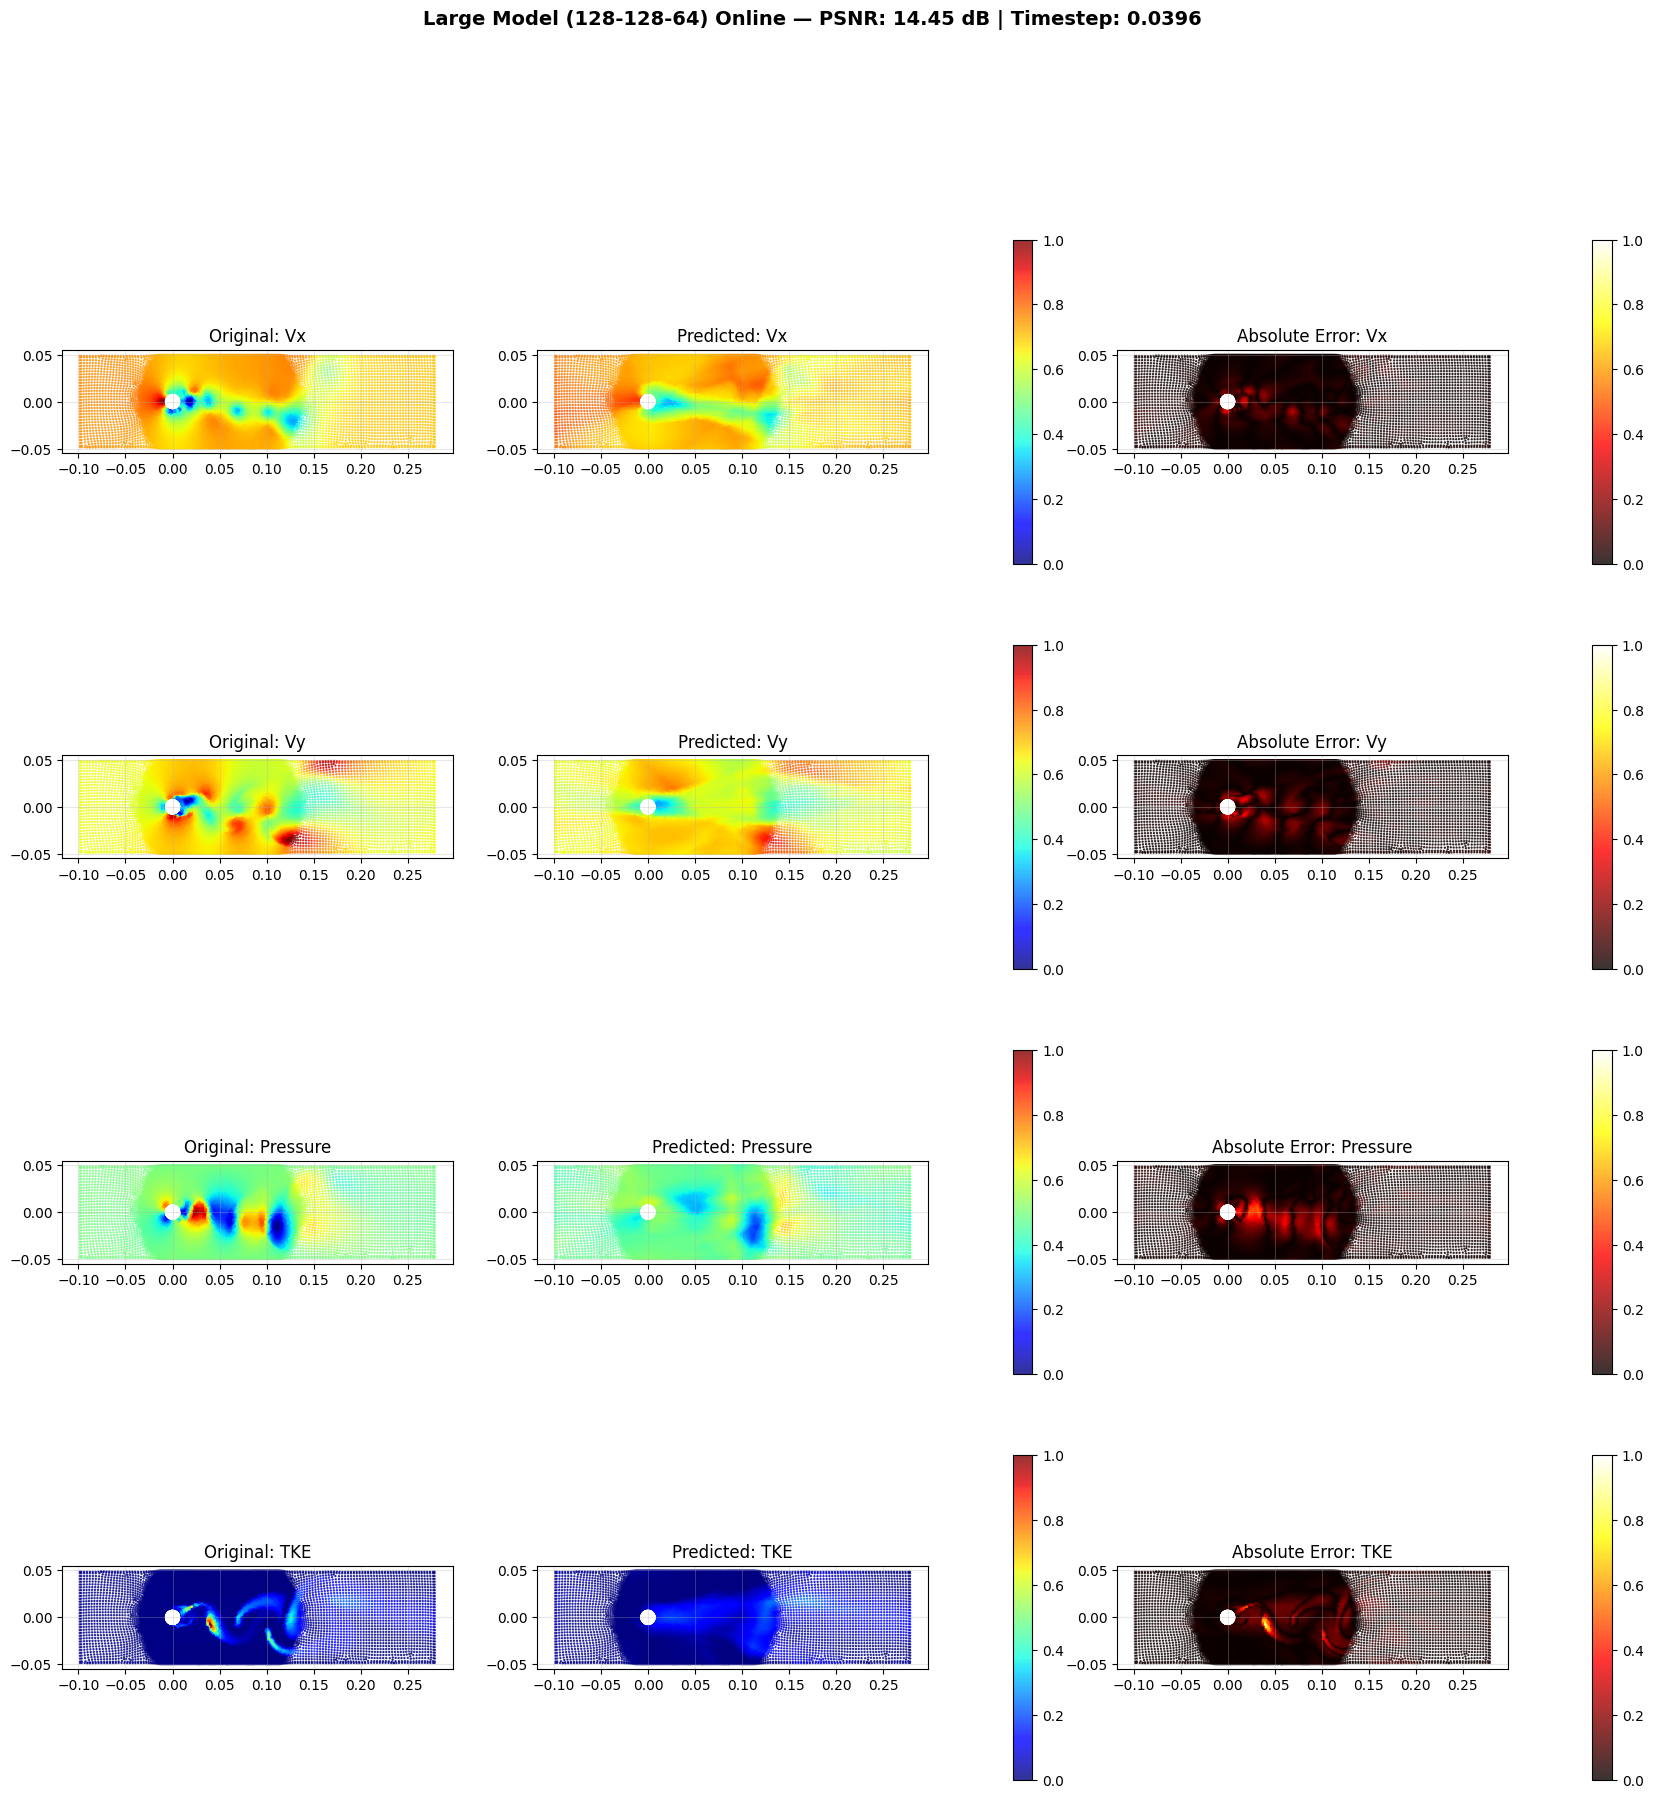

[Eval] Large model evaluation completed


In [14]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 20))
gs = GridSpec(4, 5, figure=fig,
              width_ratios=[1, 1, 0.05, 1, 0.05],
              wspace=0.35, hspace=0.25)

for row, (idx, name) in enumerate(zip(range(4), feature_names)):
    original = target_t[:, idx]
    predicted = large_pred_t[:, idx]
    error = large_errors_t[:, idx]

    ax0 = fig.add_subplot(gs[row, 0])
    ax0.scatter(x, y, c=original, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax0.set_title(f'Original: {name}')
    ax0.set_aspect('equal')
    ax0.grid(True, alpha=0.3)

    ax1 = fig.add_subplot(gs[row, 1])
    sc2 = ax1.scatter(x, y, c=predicted, cmap='jet', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax1.set_title(f'Predicted: {name}')
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)

    cax1 = fig.add_subplot(gs[row, 2])
    fig.colorbar(sc2, cax=cax1)

    ax2 = fig.add_subplot(gs[row, 3])
    sc3 = ax2.scatter(x, y, c=error, cmap='hot', s=0.5, alpha=0.8, vmin=0, vmax=1)
    ax2.set_title(f'Absolute Error: {name}')
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)

    cax2 = fig.add_subplot(gs[row, 4])
    fig.colorbar(sc3, cax=cax2)

fig.suptitle(f'Large Model (128-128-64) Online — PSNR: {large_psnr:.2f} dB | Timestep: {TIMESTEP}',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig(f"{LARGE_OUTPUT_DIR}/large_online_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

large_eval = {
    'model': 'large_model_online_final.pth',
    'architecture': '4-128-128-64-4',
    'training_mode': 'online_streaming',
    'parameters': sum(p.numel() for p in large_model.parameters()),
    'psnr_db': float(large_psnr),
    'ssim': float(large_ssim),
    'relative_error_pct': float(large_rel_error)
}
with open(f"{LARGE_OUTPUT_DIR}/evaluation_metrics.json", 'w') as f:
    json.dump(large_eval, f, indent=2)
print("[Eval] Large model evaluation completed")

---
## 4. Combined Comparison — All Three Models

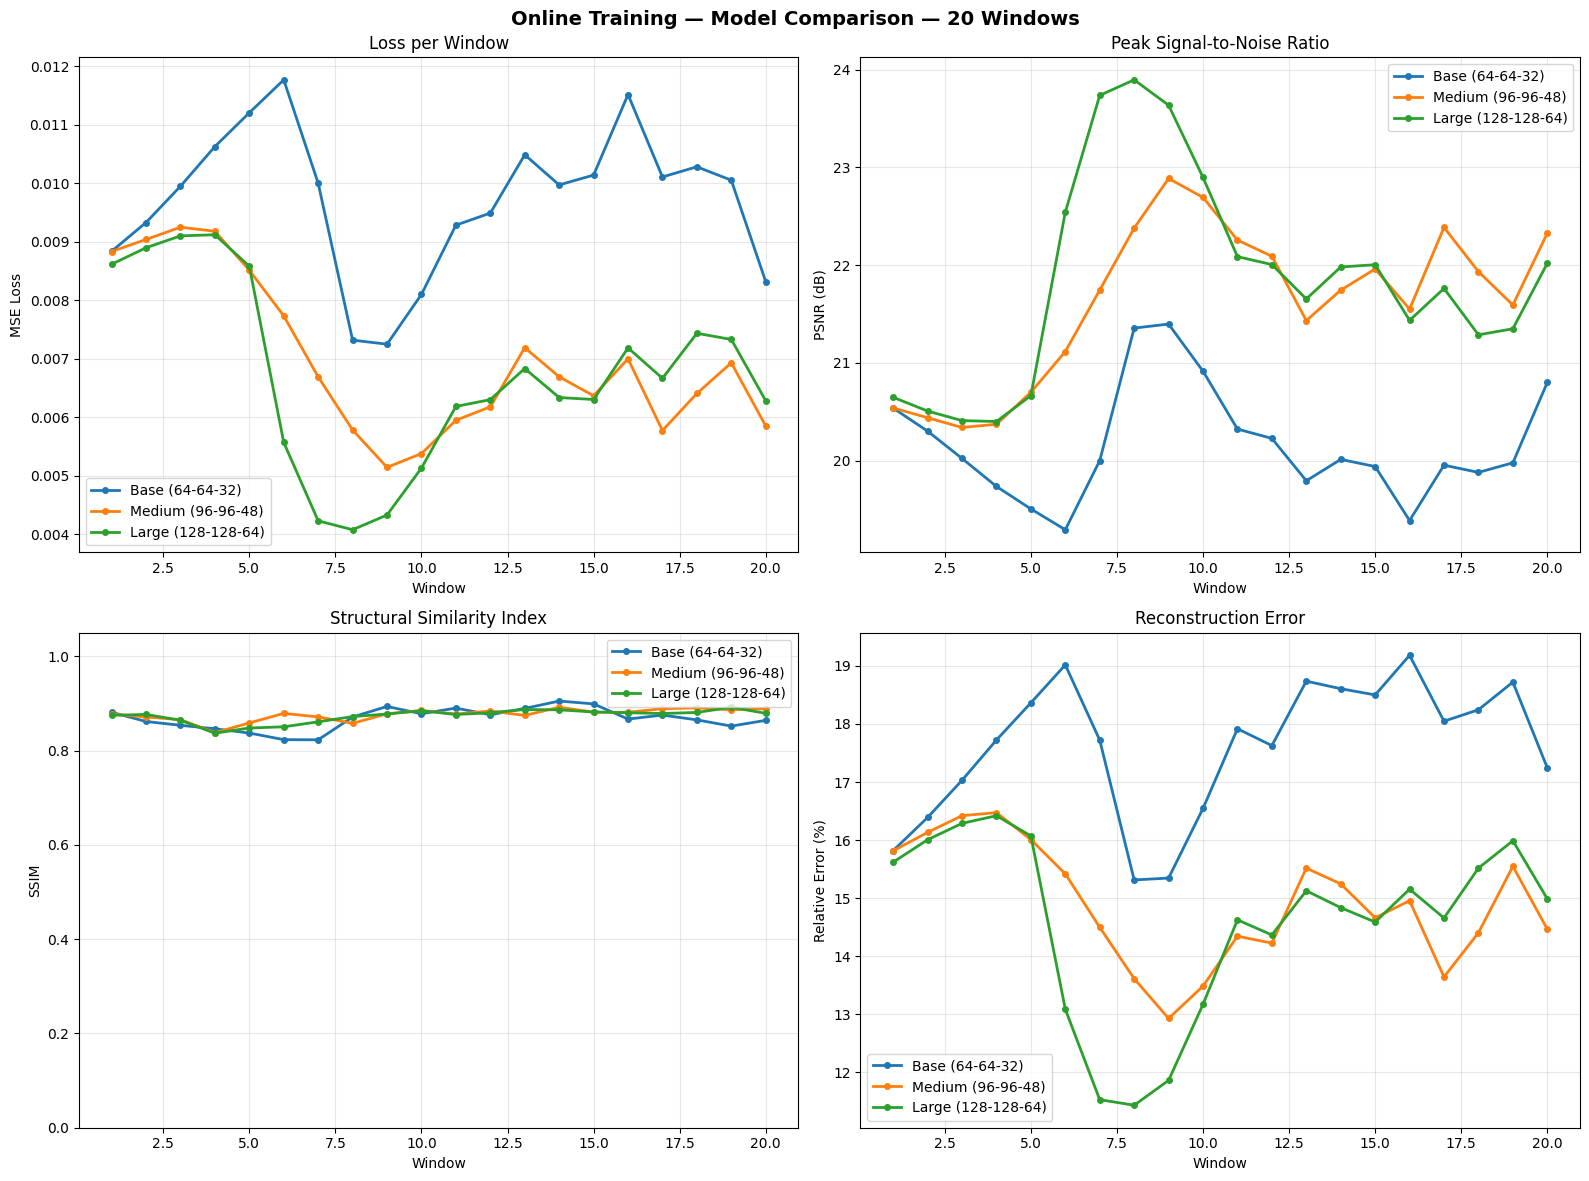

In [15]:
COMPARISON_DIR = "/kaggle/working/results/comparison_online"
os.makedirs(COMPARISON_DIR, exist_ok=True)

# Combined training progress: PSNR, MSE Loss, SSIM in same figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_data = [
    ('Base (64-64-32)', base_metrics, 'tab:blue'),
    ('Medium (96-96-48)', medium_metrics, 'tab:orange'),
    ('Large (128-128-64)', large_metrics, 'tab:green')
]

for label, m, color in models_data:
    axes[0, 0].plot(m['window'], m['loss'], '-o', color=color, linewidth=2, markersize=4, label=label)
    axes[0, 1].plot(m['window'], m['psnr'], '-o', color=color, linewidth=2, markersize=4, label=label)
    axes[1, 0].plot(m['window'], m['ssim'], '-o', color=color, linewidth=2, markersize=4, label=label)
    axes[1, 1].plot(m['window'], m['relative_error'], '-o', color=color, linewidth=2, markersize=4, label=label)

axes[0, 0].set_xlabel('Window')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Loss per Window')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].set_xlabel('Window')
axes[0, 1].set_ylabel('PSNR (dB)')
axes[0, 1].set_title('Peak Signal-to-Noise Ratio')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].set_xlabel('Window')
axes[1, 0].set_ylabel('SSIM')
axes[1, 0].set_title('Structural Similarity Index')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].legend()

axes[1, 1].set_xlabel('Window')
axes[1, 1].set_ylabel('Relative Error (%)')
axes[1, 1].set_title('Reconstruction Error')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.suptitle(f'Online Training \u2014 Model Comparison \u2014 {NUM_WINDOWS} Windows',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/online_training_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

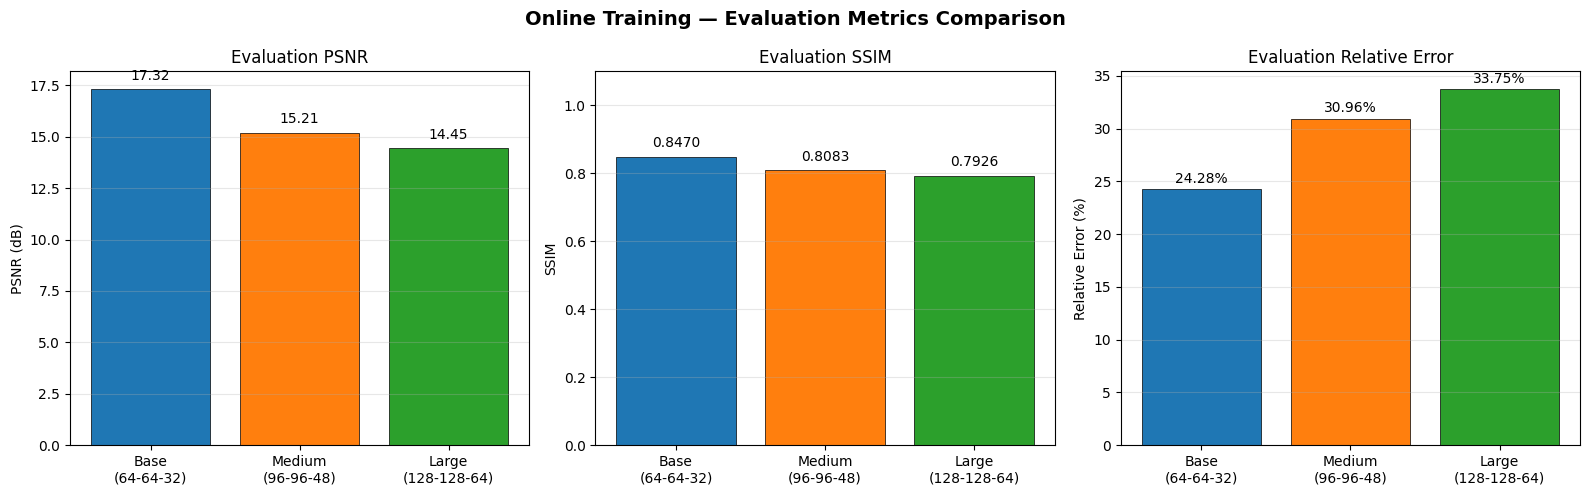

In [16]:
# Combined evaluation bar chart
model_names = ['Base\n(64-64-32)', 'Medium\n(96-96-48)', 'Large\n(128-128-64)']
eval_psnrs = [base_psnr, medium_psnr, large_psnr]
eval_ssims = [base_ssim, medium_ssim, large_ssim]
eval_errors = [base_rel_error, medium_rel_error, large_rel_error]
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars1 = axes[0].bar(model_names, eval_psnrs, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Evaluation PSNR')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, eval_psnrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=10)

bars2 = axes[1].bar(model_names, eval_ssims, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('SSIM')
axes[1].set_title('Evaluation SSIM')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim([0, 1.1])
for bar, val in zip(bars2, eval_ssims):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10)

bars3 = axes[2].bar(model_names, eval_errors, color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('Relative Error (%)')
axes[2].set_title('Evaluation Relative Error')
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, eval_errors):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Online Training \u2014 Evaluation Metrics Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/online_evaluation_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print("=" * 80)
print("ONLINE TRAINING \u2014 THREE-MODEL COMPARISON SUMMARY")
print("=" * 80)
print(f"{'Metric':<28} {'Base (64-64-32)':>16} {'Medium (96-96-48)':>18} {'Large (128-128-64)':>20}")
print("-" * 80)
print(f"{'Parameters':<28} {sum(p.numel() for p in base_model.parameters()):>16,} {sum(p.numel() for p in medium_model.parameters()):>18,} {sum(p.numel() for p in large_model.parameters()):>20,}")
print(f"{'Model Size (KB)':<28} {sum(p.numel() for p in base_model.parameters()) * 4 / 1024:>16.2f} {sum(p.numel() for p in medium_model.parameters()) * 4 / 1024:>18.2f} {sum(p.numel() for p in large_model.parameters()) * 4 / 1024:>20.2f}")
print(f"{'Windows':<28} {NUM_WINDOWS:>16} {NUM_WINDOWS:>18} {NUM_WINDOWS:>20}")
print(f"{'Epochs/Window':<28} {EPOCHS_PER_WINDOW:>16} {EPOCHS_PER_WINDOW:>18} {EPOCHS_PER_WINDOW:>20}")
print(f"{'Total Epochs':<28} {NUM_WINDOWS * EPOCHS_PER_WINDOW:>16} {NUM_WINDOWS * EPOCHS_PER_WINDOW:>18} {NUM_WINDOWS * EPOCHS_PER_WINDOW:>20}")
print("-" * 80)
print(f"{'Last Window Loss':<28} {base_metrics['loss'][-1]:>16.6f} {medium_metrics['loss'][-1]:>18.6f} {large_metrics['loss'][-1]:>20.6f}")
print(f"{'Last Window PSNR (dB)':<28} {base_metrics['psnr'][-1]:>16.2f} {medium_metrics['psnr'][-1]:>18.2f} {large_metrics['psnr'][-1]:>20.2f}")
print(f"{'Last Window SSIM':<28} {base_metrics['ssim'][-1]:>16.4f} {medium_metrics['ssim'][-1]:>18.4f} {large_metrics['ssim'][-1]:>20.4f}")
print("-" * 80)
print(f"{'Eval PSNR (dB)':<28} {base_psnr:>16.2f} {medium_psnr:>18.2f} {large_psnr:>20.2f}")
print(f"{'Eval SSIM':<28} {base_ssim:>16.4f} {medium_ssim:>18.4f} {large_ssim:>20.4f}")
print(f"{'Eval Rel. Error (%)':<28} {base_rel_error:>16.2f} {medium_rel_error:>18.2f} {large_rel_error:>20.2f}")
print(f"{'Total Training Time (s)':<28} {sum(base_metrics['time_per_window']):>16.2f} {sum(medium_metrics['time_per_window']):>18.2f} {sum(large_metrics['time_per_window']):>20.2f}")
print("=" * 80)

ONLINE TRAINING — THREE-MODEL COMPARISON SUMMARY
Metric                        Base (64-64-32)  Medium (96-96-48)   Large (128-128-64)
--------------------------------------------------------------------------------
Parameters                              6,692             14,644               25,668
Model Size (KB)                         26.14              57.20               100.27
Windows                                    20                 20                   20
Epochs/Window                             100                100                  100
Total Epochs                             2000               2000                 2000
--------------------------------------------------------------------------------
Last Window Loss                     0.008319           0.005853             0.006284
Last Window PSNR (dB)                   20.80              22.33                22.02
Last Window SSIM                       0.8643             0.8891               0.8792
---------------

---
## 5. Single-Axis Metric Comparisons (All Models Overlaid)

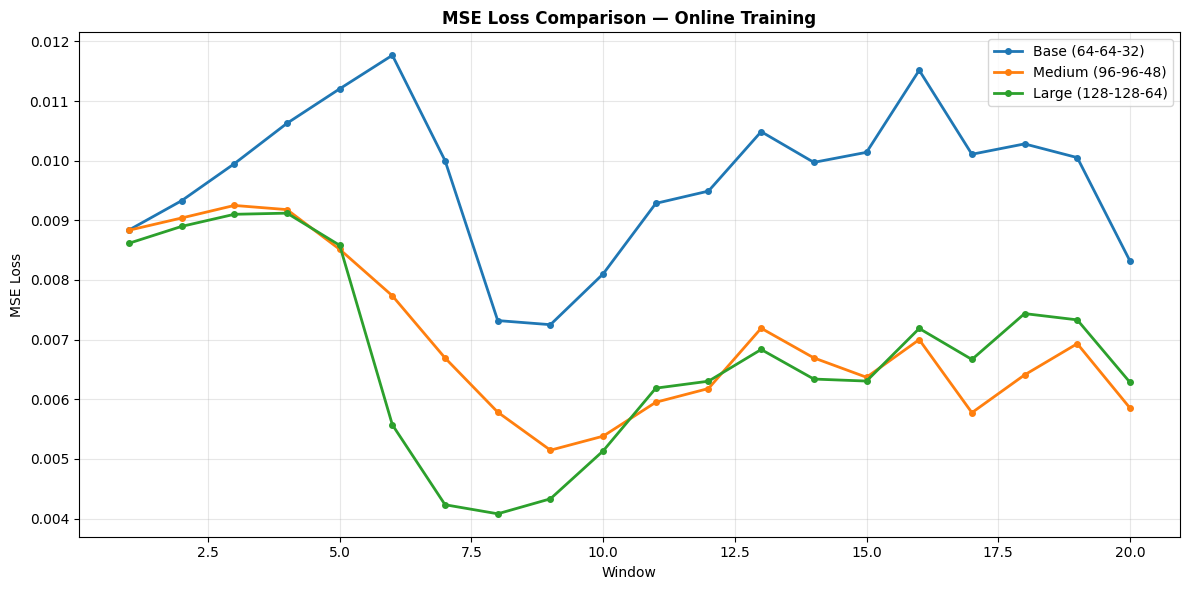

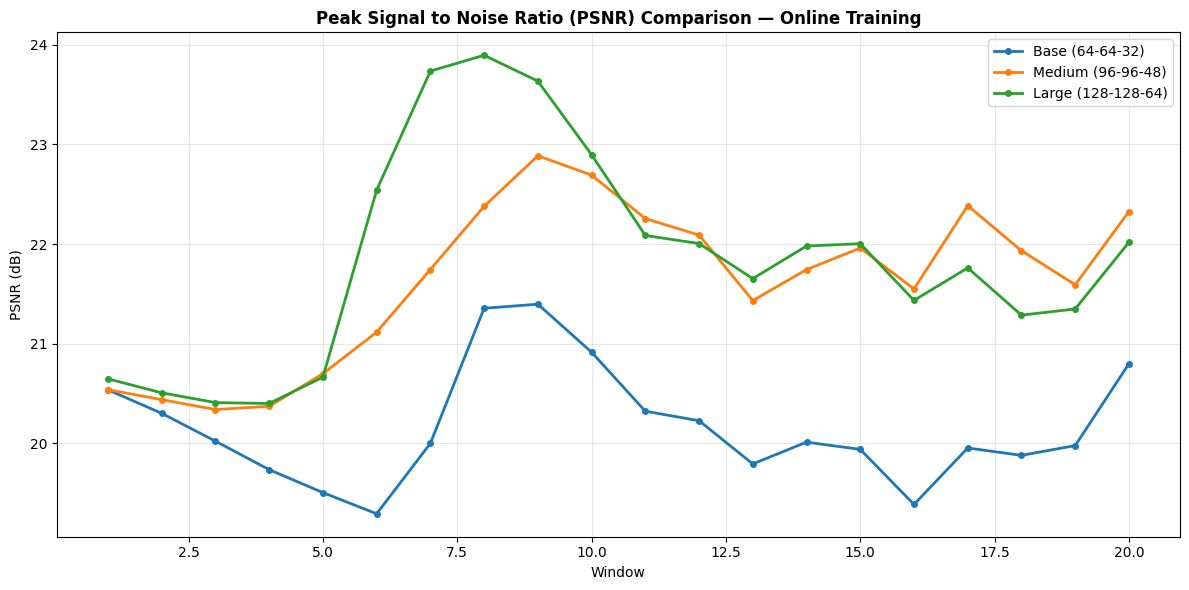

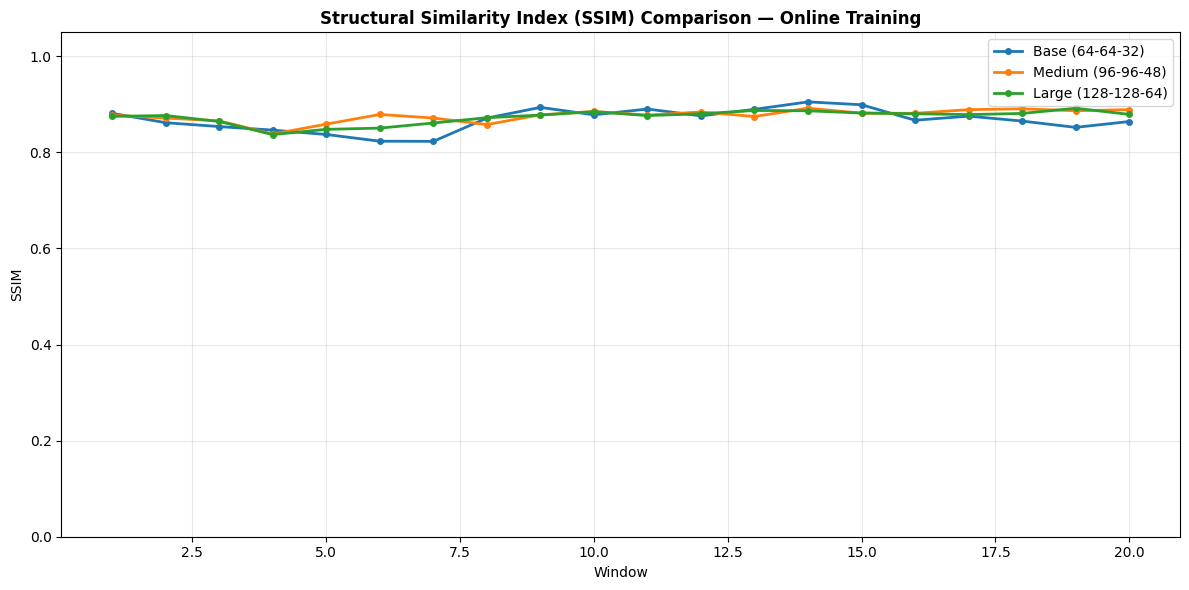

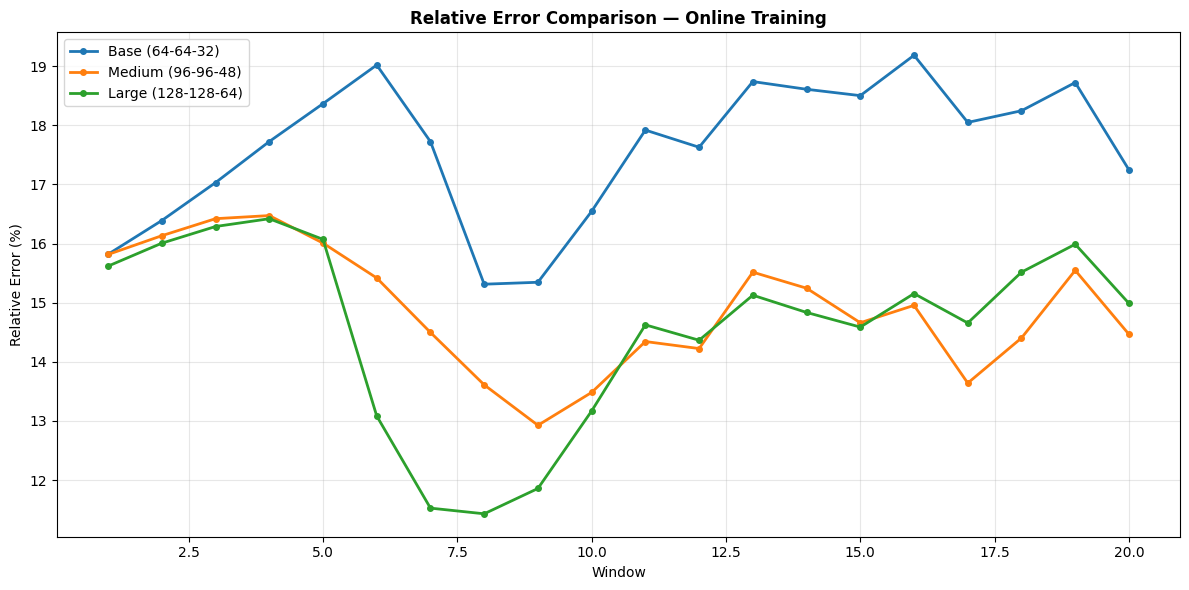

All comparison plots saved to /kaggle/working/results/comparison_online/


In [18]:
models_overlay = [
    ('Base (64-64-32)', base_metrics, 'tab:blue'),
    ('Medium (96-96-48)', medium_metrics, 'tab:orange'),
    ('Large (128-128-64)', large_metrics, 'tab:green'),
]

# MSE Loss Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    ax.plot(m['window'], m['loss'], '-o', linewidth=2, markersize=4, color=color, label=label)
ax.set_xlabel('Window')
ax.set_ylabel('MSE Loss')
ax.set_title('MSE Loss Comparison — Online Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/loss_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# PSNR Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    ax.plot(m['window'], m['psnr'], '-o', linewidth=2, markersize=4, color=color, label=label)
ax.set_xlabel('Window')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Peak Signal to Noise Ratio (PSNR) Comparison — Online Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/psnr_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# SSIM Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    ax.plot(m['window'], m['ssim'], '-o', linewidth=2, markersize=4, color=color, label=label)
ax.set_xlabel('Window')
ax.set_ylabel('SSIM')
ax.set_title('Structural Similarity Index (SSIM) Comparison — Online Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/ssim_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Relative Error Comparison
fig, ax = plt.subplots(figsize=(12, 6))
for label, m, color in models_overlay:
    ax.plot(m['window'], m['relative_error'], '-o', linewidth=2, markersize=4, color=color, label=label)
ax.set_xlabel('Window')
ax.set_ylabel('Relative Error (%)')
ax.set_title('Relative Error Comparison — Online Training', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{COMPARISON_DIR}/relative_error_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"All comparison plots saved to {COMPARISON_DIR}/")

### 6. Save and Download

In [19]:
# Package all results into a single zip for download

import shutil

zip_path = shutil.make_archive(
    '/kaggle/working/all_results',
    'zip',
    '/kaggle/working/results'
)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print("Results archived to: {}".format(zip_path))
print("Archive size: {:.1f} MB".format(zip_size_mb))

Results archived to: /kaggle/working/all_results.zip
Archive size: 12.3 MB
